# **Network Data Analysis Laboratory — Federated Learning on Jakarta IXPs**

**Team:** 12

* Luca Bordin (luca1.bordin@mail.polimi.it)

* Mattia Menegale (mattia.menegale@mail.polimi.it)

* Francesco Cavalieri (francesco1.cavalieri@mail.polimi.it)

**Course:** Network Measurement And Data Analysis Lab 2025/2026

---

## **Notebook Goal**
This notebook is the **Federated Learning (advanced task)**, which simulates **Federated Learning across Jakarta's IXPs** using **FedAvg** on top of a shared single-layer **GRU** forecaster.

Candidate clients are drawn from 15 Jakarta profiles. The clients are divided into 12 **training IXPs** and **3 held-out IXPs** that never participate in any training round.

Three baselines are trained on the **same** forecasting task and compared head-to-head:

* **Local-only** — one independent GRU per participating client, trained only on that client's data.
* **Federated (FedAvg)** — one global GRU shared across clients.
* **Centralized** — one GRU trained on the pool of all participants' (standardized) data; the practical upper bound.

## **Forecasting Task & Key Design Choices**

* **Task — hourly, multi-step:** given the past **24 hours** (`lookback = 24`), forecast the next **6 hours** (`horizon = 6`). Hourly resolution keeps each local update less noisy and the FL loop wall-clock tractable.
* **Architecture — single-layer GRU** shared across all three baselines so any performance gap reflects *what data the model saw*, not the model itself. GRU over LSTM for fewer parameters (less per-round bandwidth) and faster training on small per-client datasets.

## S0 Imports, paths and reproducibility

In [ ]:
# ========================
# Imports
# ========================

import os
import ast
import copy
import json
import time

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mount Google Drive when running on Colab. If not on Colab, the notebook
# assumes the data paths below are already reachable on the local filesystem.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running on Colab: assuming the dataset paths are already accessible.")


Mounted at /content/drive


In [ ]:
# ========================
# Paths
# ========================

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/NDA_PROJECT/MAIN")

DATASET_DIR = PROJECT_DIR / "ixp-traffic-dataset"
DATA_DIR = DATASET_DIR / "data"

METADATA_FILE_PATH = DATA_DIR / "metadata.csv"
TRAFFIC_PROFILES_DIR = DATA_DIR / "profiles"

# PeeringDB public API endpoint for Internet Exchange Points.
PEERINGDB_URL = "https://www.peeringdb.com/api/ix"

# Download the dataset from GitHub only if it is not already cached on Drive.
DATASET_REPO_URL = "https://github.com/nsg-ethz/ixp-traffic-dataset.git"

if METADATA_FILE_PATH.exists() and TRAFFIC_PROFILES_DIR.exists():
    print(f"Dataset already cached on Drive at {DATASET_DIR} -> skipping download.")
else:
    print("Dataset not found on Drive -> downloading from GitHub (may take a while)...")
    PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    !git clone --depth 1 "$DATASET_REPO_URL" "$DATASET_DIR"

required_paths = [PROJECT_DIR, DATASET_DIR, DATA_DIR, METADATA_FILE_PATH, TRAFFIC_PROFILES_DIR]
for path in required_paths:
    print(path, "->", path.exists())

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n" + "\n".join(missing))


Dataset already cached on Drive at /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset -> skipping download.
/content/drive/MyDrive/NDA_PROJECT/MAIN -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/metadata.csv -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/profiles -> True


In [ ]:
# ========================
# Reproducibility
# ========================

SEED = 42

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## S0.1 PeeringDB loader

The traffic dataset metadata contains IXP IDs but no geographic information, so we use
PeeringDB to map IDs to cities/countries. Results are cached locally to avoid repeated
(rate-limited) API calls.

In [ ]:
# ========================
# PeeringDB loader
# ========================

#Normalize raw PeeringDB
def _normalize_peeringdb_record(record):
    ixp_id = record.get("Id", record.get("id"))
    return {
        "Id": int(ixp_id),
        "Name": record.get("Name", record.get("name")),
        "City": record.get("City", record.get("city")),
        "Country": record.get("Country", record.get("country")),
        "Website": record.get("Website", record.get("website")),
    }

#Load IXPs from PeeringDB (cache-first).
def load_peeringdb_ixps(cache_path, query_params, fields="id,name,city,country,website"):
    cache_path = Path(cache_path)

    if cache_path.exists():
        with open(cache_path, "r") as f:
            records = json.load(f)
        print(f"Loaded {len(records)} IXPs from cache: {cache_path}")
    else:
        params = {**query_params, "fields": fields}
        headers = {"User-Agent": "Polimi-NDA-Project/1.0"}

        response = requests.get(PEERINGDB_URL, params=params, headers=headers, timeout=60)
        print("Requested URL:", response.url, "| status:", response.status_code)
        response.raise_for_status()

        records = [_normalize_peeringdb_record(r) for r in response.json().get("data", [])]
        with open(cache_path, "w") as f:
            json.dump(records, f, indent=2)
        print(f"Fetched and cached {len(records)} IXPs -> {cache_path}")

    records = [_normalize_peeringdb_record(r) for r in records]
    ixp_df = pd.DataFrame(records)
    if not ixp_df.empty:
        ixp_df["Id"] = ixp_df["Id"].astype(int)
    return ixp_df

#Convert the PeeringDB DataFrame to a dict keyed by IXP ID.
def peeringdb_dataframe_to_info_dict(ixp_df):
    return {
        int(row["Id"]): {
            "id": int(row["Id"]),
            "name": row.get("Name"),
            "city": row.get("City"),
            "country": row.get("Country"),
            "website": row.get("Website"),
        }
        for _, row in ixp_df.iterrows()
    }


## S0.2 Core forecasting utilities

Per-client standardization, sliding-window construction and a PyTorch DataLoader helper.
The **scaler is fitted only on each client's own training split**, which both avoids
leakage and reflects the federated assumption that an IXP never shares its raw data.

In [ ]:
# ========================
# Standardizer / windows / loader
# ========================

class Standardizer:
    def fit(self, values):
        self.mean = float(np.mean(values))
        self.std = max(float(np.std(values)), 1e-8)
        return self

    def transform(self, values):
        return (values - self.mean) / self.std

    def inverse(self, values):
        return values * self.std + self.mean

#Build (X, Y) sliding windows: X = past n_lookback steps, Y = next k_horizon steps.
def make_windows(values, n_lookback, k_horizon, stride=1):
    values = np.asarray(values, dtype=np.float32)
    X, Y = [], []
    last_start = len(values) - n_lookback - k_horizon
    for start in range(0, last_start + 1, stride):
        X.append(values[start:start + n_lookback])
        Y.append(values[start + n_lookback:start + n_lookback + k_horizon])
    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.float32)


def make_loader(X, Y, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


## S0.3 Objective, comparable metrics

The IXPs in this simulation span four orders of magnitude in traffic, so the metric must
be **scale-free** to be comparable across clients and to be aggregated meaningfully.

* **Raw MAE / RMSE are reported only for reference.** They are in Gbit/s, so a mean MAE
  across clients is dominated by the single largest IXP and is not comparable.
* **NMAE% / NRMSE%** normalize the error by the IXP's own mean traffic level, giving a
  comparable "error as a fraction of typical load".
* **R²** is dimensionless and directly comparable across clients.
* **Skill vs. persistence** is the objective sanity check: it measures how much the model
  beats a naive forecast that simply repeats the last observed value over the horizon.
  A skill `> 0` means the model is genuinely useful; `<= 0` means it does not beat naive.

Aggregation across the held-out IXPs uses the **mean of the scale-free metrics**
(NMAE%, R², skill), never the mean of raw MAE.

In [ ]:
# ========================
# Forecast metrics
# ========================

def compute_forecast_metrics(y_true, y_pred, y_persist=None):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    mean_level = np.mean(np.abs(y_true))
    nmae = 100.0 * mae / max(mean_level, 1e-9)
    nrmse = 100.0 * rmse / max(mean_level, 1e-9)

    r2 = r2_score(y_true, y_pred)

    metrics = {
        "MAE_Gbps": mae,
        "RMSE_Gbps": rmse,
        "NMAE_pct": nmae,
        "NRMSE_pct": nrmse,
        "R2": r2,
    }

    if y_persist is not None:
        y_persist = np.asarray(y_persist, dtype=np.float64).ravel()
        mae_persist = mean_absolute_error(y_true, y_persist)
        metrics["MAE_persistence_Gbps"] = mae_persist
        # Skill: model_error / naive_error > 0 means better than naive.
        metrics["skill_vs_persistence"] = 1.0 - mae / max(mae_persist, 1e-9)

    return metrics


def persistence_prediction(X_window, k_horizon):
    """Naive baseline: repeat the last lookback value over the whole horizon.

    X_window is in standardized space; the caller inverse-transforms the result.
    """
    last_value = X_window[:, -1:]
    return np.repeat(last_value, k_horizon, axis=1)


## S0.4 GRU model, trainer and predictor

A single GRU architecture is shared by every client (local, federated and centralized).
`train_torch_forecaster` is a generic early-stopping trainer reused by the centralized
and local baselines.

In [ ]:
# ========================
# GRU model
# ========================

class FederatedGRUForecaster(nn.Module):
    def __init__(self, horizon, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # (batch, lookback) -> (batch, lookback, 1)
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


In [ ]:
# ========================
# Generic trainer + predictor
# ========================

def train_torch_forecaster(model, X_train, Y_train, X_validation, Y_validation,
                           learning_rate, max_epochs, patience, batch_size, verbose=False):
    train_loader = make_loader(X_train, Y_train, batch_size, shuffle=True)
    validation_loader = make_loader(X_validation, Y_validation, batch_size, shuffle=False)

    model = model.to(DEVICE)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_validation_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    bad_epochs = 0
    history = {"train_loss": [], "validation_loss": []}

    start_time = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * len(xb)
        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        validation_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in validation_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                validation_loss_sum += loss_fn(model(xb), yb).item() * len(xb)
        validation_loss = validation_loss_sum / len(validation_loader.dataset)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(validation_loss)
        if verbose:
            print(f"Epoch {epoch:02d} | train MSE: {train_loss:.5f} | val MSE: {validation_loss:.5f}")

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print("Early stopping")
                break

    training_time = time.time() - start_time
    model.load_state_dict(best_state)
    return model, history, best_validation_loss, training_time


def predict_torch_model(model, X, batch_size=1024):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[start:start + batch_size]).to(DEVICE)
            predictions.append(model(xb).cpu().numpy())
    return np.concatenate(predictions)


## S1.1 Federated Learning configuration

We use **hourly** traffic series (5-minute data resampled to 1 h) to keep per-client
training stable and cheap. Each client uses a 24 h lookback and a 6 h horizon. The shared
model is a small GRU.

In [ ]:
# ========================
# Federated Learning configuration
# ========================

# TOTAL NUMBER OF TARGET IXPs
FL_TARGET_IXPS = 15

# HELD-OUT IXPs
FL_TEST_IXPS = 3

# previous 24 hours
FL_N_LOOKBACK = 24

# next 6 hours
FL_K_HORIZON = 6

FL_ROUNDS = 15
FL_LOCAL_EPOCHS = 2
FL_BATCH_SIZE = 128
FL_LEARNING_RATE = 5e-4

FL_HIDDEN_SIZE = 64
FL_NUM_LAYERS = 1
FL_DROPOUT = 0.0

# FedProx proximal coefficient (0.0 = plain FedAvg).
FL_MU = 0.01

# Minimum number of hourly samples required for a usable IXP.
FL_MIN_SAMPLES = 5000

# Zero-traffic removal
# IXPs whose mean hourly throughput is below this threshold are dead/empty
# series and are removed from the entire simulation.
FL_MIN_MEAN_GBPS = 0.05

# Jakarta-only filtering
# Greater-Jakarta (Jabodetabek) city tokens. A PeeringDB IXP counts as a
# Jakarta IXP if its city field contains one of these tokens.
JAKARTA_CITY_TOKENS = {
    "jakarta", "jabodetabek", "jkt",
    "bekasi", "tangerang", "depok", "bogor", "cikarang", "serpong", "bsd",
}

# Jakarta IXPs PeeringDB mislabels
JAKARTA_IXP_ID_WHITELIST = {375}

# Fair comparison: budget for the local and centralized baselines
BASELINE_MAX_EPOCHS = 40
BASELINE_PATIENCE = 6

print("FL configuration")
print("  target IXPs:", FL_TARGET_IXPS, "| held-out:", FL_TEST_IXPS)
print("  lookback:", FL_N_LOOKBACK, "| horizon:", FL_K_HORIZON)
print("  min mean traffic kept:", FL_MIN_MEAN_GBPS, "Gbit/s")


FL configuration
  target IXPs: 15 | held-out: 3
  lookback: 24 | horizon: 6
  min mean traffic kept: 0.05 Gbit/s


## S1.2 Load PeeringDB information for Indonesia and Jakarta

We query PeeringDB for all Indonesian IXPs (`country = ID`) to obtain their city
information, which we then use to keep only the Jakarta ones.

In [ ]:
# ========================
# Load Indonesian IXPs from PeeringDB
# ========================

PEERINGDB_INDONESIA_CACHE_PATH = DATA_DIR / "peeringdb_indonesia_ixps.json"

indonesia_ixps_df = load_peeringdb_ixps(
    cache_path=PEERINGDB_INDONESIA_CACHE_PATH,
    query_params={"country": "ID"},
)

indonesia_ixps = peeringdb_dataframe_to_info_dict(indonesia_ixps_df)

print("Indonesian IXPs from PeeringDB:", len(indonesia_ixps))
display(indonesia_ixps_df.head())


Loaded 77 IXPs from cache: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/peeringdb_indonesia_ixps.json
Indonesian IXPs from PeeringDB: 77


,Id,Name,City,Country,Website
0,210,IIX-Jakarta,Jakarta,ID,https://www.apjii.or.id
1,375,OpenIXP / NiCE,Indonesia,ID,
2,452,BIX Jakarta,Jakarta,ID,http://www.biznetnetworks.com
3,606,C2IX,Jakarta,ID,https://www.nexdatacenter.com/
4,626,IIX-JawaTimur,Surabaya,ID,https://www.apjii.or.id


In [ ]:
# ========================
# Print every Indonesian IXP
# ========================

# Make this cell self-contained (works even before S1.4 has run).
if "metadata_fl" not in globals():
    metadata_fl = pd.read_csv(METADATA_FILE_PATH)
    if isinstance(metadata_fl["siblings"].iloc[0], str):
        metadata_fl["siblings"] = metadata_fl["siblings"].apply(ast.literal_eval)

if "profile_id_group" not in globals():
    def profile_id_group(row):
        return {int(row["ixp_id"])} | set(int(x) for x in row["siblings"])

diag = pd.DataFrame([
    {"id": ixp_id, "name": info["name"], "city": info["city"]}
    for ixp_id, info in sorted(indonesia_ixps.items())
])

print(f"Total Indonesian IXPs in PeeringDB: {len(diag)}")
display(diag)

# ========================
# Print every profile containing an Indonesian IXP
# ========================

indonesia_ixp_ids = set(indonesia_ixps.keys())

for _, row in metadata_fl.iterrows():
    ids = profile_id_group(row)
    if ids & indonesia_ixp_ids:
        names = [
            (ixp_id,
             indonesia_ixps.get(ixp_id, {}).get("name"),
             indonesia_ixps.get(ixp_id, {}).get("city"))
            for ixp_id in sorted(ids)
            if ixp_id in indonesia_ixp_ids
        ]
        print(f"profile {int(row['index'])} | main {int(row['ixp_id'])} | Indonesian IXPs: {names}")

Total Indonesian IXPs in PeeringDB: 77


,id,name,city
0,210,IIX-Jakarta,Jakarta
1,375,OpenIXP / NiCE,Indonesia
2,452,BIX Jakarta,Jakarta
3,606,C2IX,Jakarta
4,626,IIX-JawaTimur,Surabaya
...,...,...,...
72,4900,JDX,Jakarta
73,4904,Swin Exchange,Depok
74,4967,GENTONG IX,Batu
75,4972,PT RINJANI CITRA SOLUSI,Selong


profile 186 | main 375 | Indonesian IXPs: [(375, 'OpenIXP / NiCE', 'Indonesia')]
profile 187 | main 2476 | Indonesian IXPs: [(2476, 'JKT-IX', 'Jakarta')]
profile 226 | main 452 | Indonesian IXPs: [(452, 'BIX Jakarta', 'Jakarta')]
profile 227 | main 3339 | Indonesian IXPs: [(3339, 'BIX Semarang', 'Semarang, Central Java')]
profile 228 | main 3337 | Indonesian IXPs: [(3337, 'BIX Surabaya', 'Surabaya, East Java')]
profile 229 | main 3340 | Indonesian IXPs: [(3340, 'BIX Denpasar 1', 'Denpasar, Bali'), (3341, 'BIX Denpasar 2', 'Denpasar, Bali')]
profile 283 | main 916 | Indonesian IXPs: [(916, 'CitraIX Yogyakarta', 'Yogyakarta')]
profile 286 | main 2622 | Indonesian IXPs: [(2622, 'IIX-Bali', 'Denpasar')]
profile 334 | main 4053 | Indonesian IXPs: [(4053, 'sumIX', 'Pekanbaru')]
profile 345 | main 4066 | Indonesian IXPs: [(4066, 'CitraIX Surakarta', 'Surakarta')]
profile 353 | main 3329 | Indonesian IXPs: [(3329, 'IIX-Jateng', 'Semarang')]
profile 367 | main 3970 | Indonesian IXPs: [(3970, 'S

We see that there are exactly 77 IXPs labeled as "Indonesian" according to PeeringDB

Now let's see how many IXPs there are in Jakarta according to PeeringDB

In [ ]:
from collections import Counter

# IXPs that actually have a traffic profile in the dataset
prof_count = Counter()
for _, row in metadata_fl.iterrows():
    for i in profile_id_group(row):
        prof_count[i] += 1

# Greater-Jakarta city tokens (Jabodetabek), not just literal "jakarta"
JKT_TOKENS = {"jakarta", "jkt", "bekasi", "bogor", "depok", "tangerang"}
# Jakarta IXPs PeeringDB mislabels (city = "Indonesia"/blank/other)
JKT_WHITELIST = {375}   # OpenIXP / NiCE

def is_jkt(info):
    c = (info.get("city") or "").lower()
    return any(t in c for t in JKT_TOKENS)

jakarta_real = {
    i for i, info in indonesia_ixps.items()
    if (is_jkt(info) or i in JKT_WHITELIST)
}

print(f"jakarta_real: {len(jakarta_real)} IXPs\n")
print(f"{'id':>5}  {'city':<18} name")
for i in sorted(jakarta_real):
    info = indonesia_ixps[i]
    print(f"{i:>5}  {str(info['city']):<18} {info['name']}")

jakarta_real: 34 IXPs

   id  city               name
  210  Jakarta            IIX-Jakarta
  375  Indonesia          OpenIXP / NiCE
  452  Jakarta            BIX Jakarta
  606  Jakarta            C2IX
 1054  Jakarta            Transhybrid IX Network
 1228  Jakarta            CDIX
 2476  Jakarta            JKT-IX
 2670  Jakarta            BatamIX Jakarta
 2737  Jakarta            CXC Jakarta
 3170  Bekasi             DCI Indonesia DCI-IX
 3387  Jakarta            NCJX-Neutral Connect J-Xchange
 3532  Jakarta            CNI-IX
 3671  Jakarta            NCIX - neuCentrIX
 3952  Jakarta            Matrix Internet Exchange (MIX)
 3970  Bogor              Super Internet eXchange (SIX)
 4011  Pekanbaru - Jakarta CENTRO-IX
 4012  Jakarta            Pejuang IX
 4047  Jakarta            Digital Edge EPIX Jakarta
 4163  Jakarta            EdgeNXT
 4191  Jakarta            Metta-IX
 4405  Jakarta            IFORTE Xchange
 4411  Jakarta            DE-CIX Jakarta
 4432  Jakarta            JAMUANFC

## S1.3 Keep only Jakarta IXPs

We filter the Indonesian IXP list down to the **Jakarta metropolitan area** using the
PeeringDB city field. This relies on PeeringDB metadata, so any Jakarta IXP whose city is
missing or mislabeled (e.g. listed only as "Indonesia") will be conservatively excluded

In [ ]:
# ========================
# Build the Jakarta IXP-ID set
# ========================

def city_is_jakarta(city):
    if not isinstance(city, str):
        return False
    c = city.strip().lower()
    return any(token in c for token in JAKARTA_CITY_TOKENS)

jakarta_ixp_ids = {
    ixp_id for ixp_id, info in indonesia_ixps.items()
    if city_is_jakarta(info.get("city"))
} | JAKARTA_IXP_ID_WHITELIST

print("Jakarta IXPs kept:", len(jakarta_ixp_ids), "/", len(indonesia_ixps), "Indonesian IXPs")
print()
print("All Jakarta IXPs kept:")
for ixp_id in sorted(jakarta_ixp_ids):
    info = indonesia_ixps[ixp_id]
    print(f"  [{ixp_id}] {info['name']}  ({info['city']})")


Jakarta IXPs kept: 34 / 77 Indonesian IXPs

All Jakarta IXPs kept:
  [210] IIX-Jakarta  (Jakarta)
  [375] OpenIXP / NiCE  (Indonesia)
  [452] BIX Jakarta  (Jakarta)
  [606] C2IX  (Jakarta)
  [1054] Transhybrid IX Network  (Jakarta)
  [1228] CDIX  (Jakarta)
  [2476] JKT-IX  (Jakarta)
  [2670] BatamIX Jakarta  (Jakarta)
  [2737] CXC Jakarta  (Jakarta)
  [3170] DCI Indonesia DCI-IX  (Bekasi)
  [3387] NCJX-Neutral Connect J-Xchange  (Jakarta)
  [3532] CNI-IX  (Jakarta)
  [3671] NCIX - neuCentrIX  (Jakarta)
  [3952] Matrix Internet Exchange (MIX)  (Jakarta)
  [3970] Super Internet eXchange (SIX)  (Bogor)
  [4011] CENTRO-IX  (Pekanbaru - Jakarta)
  [4012] Pejuang IX  (Jakarta)
  [4047] Digital Edge EPIX Jakarta  (Jakarta)
  [4163] EdgeNXT  (Jakarta)
  [4191] Metta-IX  (Jakarta)
  [4405] IFORTE Xchange  (Jakarta)
  [4411] DE-CIX Jakarta  (Jakarta)
  [4432] JAMUANFC-IX  (Jakarta)
  [4434] INTERLINK IXP  (Jakarta)
  [4449] AIX  (Tapos, Depok)
  [4510] MONICA IX (AS 138121)  (Jakarta)
  [4555] A

We see that there are only 34 IXPs in Jakarta according to PeeringDB. We need to be sure that at least 15 of them are included in our dataset.

## S1.4 Match dataset profiles to Jakarta IXPs



We actually see that, according to PeeringDB, there are only 6 IXPs from Jakarta with a profile in our dataset. So, in the next section, we'll expand the candidates IXPs for our experiment including also other Indonesian IXPs in order to have exactly 15 IXPs to perform the experiment.

Each traffic profile in `metadata.csv` has a main `ixp_id` (and possibly `siblings`).
We build the candidate pool in two priority groups, looking only at the profile's
**main IXP** (siblings are not checked):

* **Jakarta profiles** — the profile's main `ixp_id` is a Jakarta IXP.
* **Other Indonesian profiles** — the main IXP is Indonesian but not Jakarta; these pad
  the pool up to 15 when Jakarta alone is not enough.

The final cut to exactly `FL_TARGET_IXPS` (15) happens in 1.6, after dropping
zero-traffic IXPs, and always takes the Jakarta profiles first.

In [ ]:
# ========================
# Match dataset profiles to Jakarta / Indonesian IXPs
# ========================

metadata_fl = pd.read_csv(METADATA_FILE_PATH)

if isinstance(metadata_fl["siblings"].iloc[0], str):
    metadata_fl["siblings"] = metadata_fl["siblings"].apply(ast.literal_eval)

def profile_id_group(row):
    """Full set of IXP IDs represented by one profile: main id + siblings."""
    return {int(row["ixp_id"])} | set(int(x) for x in row["siblings"])

indonesia_ixp_ids = set(indonesia_ixps.keys())

# A profile is classified by its MAIN ixp_id only (siblings ignored).
metadata_fl["is_jakarta"] = metadata_fl["ixp_id"].astype(int).isin(jakarta_ixp_ids)
metadata_fl["is_indonesia"] = metadata_fl["ixp_id"].astype(int).isin(indonesia_ixp_ids)

jakarta_profiles = metadata_fl[metadata_fl["is_jakarta"]].copy()

print("Profiles whose main IXP is in Jakarta:", len(jakarta_profiles))
display(jakarta_profiles.head())

Profiles whose main IXP is in Jakarta: 6


,index,ixp_id,siblings,is_jakarta,is_indonesia
165,186,375,[],True,True
166,187,2476,[],True,True
204,226,452,[],True,True
328,367,3970,[],True,True
345,385,210,[],True,True


### Candidate pool: Jakarta first, then other Indonesian profiles

Jakarta profiles go to the front of the pool; all remaining profiles whose main IXP is
Indonesian follow and are used only to fill spots up to 15. The actual selection (and the
zero-traffic drop) happens in S1.5–S1.6.

In [ ]:
# ========================
# Build the candidate pool: Jakarta profiles first, then other Indonesian profiles
# ========================

# Group 1: profiles whose main IXP is in Jakarta.
jakarta_main_profiles = metadata_fl[metadata_fl["is_jakarta"]].copy()

# Group 2: other profiles whose main IXP is Indonesian (and not already Jakarta).
other_indonesia_profiles = metadata_fl[
    metadata_fl["is_indonesia"] & ~metadata_fl["is_jakarta"]
].copy()

# Candidate pool, Jakarta ones first. Cut to FL_TARGET_IXPS happens in S1.6,
# after zero-traffic IXPs are dropped.
jakarta_pool_profiles = pd.concat(
    [jakarta_main_profiles, other_indonesia_profiles],
    ignore_index=True,
)

print("Jakarta profiles (main IXP in Jakarta):", len(jakarta_main_profiles))
print("Other Indonesian profiles            :", len(other_indonesia_profiles))
print("Total candidate pool                 :", len(jakarta_pool_profiles))
display(jakarta_pool_profiles.head())

Jakarta profiles (main IXP in Jakarta): 6
Other Indonesian profiles            : 10
Total candidate pool                 : 16


,index,ixp_id,siblings,is_jakarta,is_indonesia
0,186,375,[],True,True
1,187,2476,[],True,True
2,226,452,[],True,True
3,367,3970,[],True,True
4,385,210,[],True,True


## S1.5 Load hourly series and drop zero-traffic IXPs

We take **all** profiles in the candidate pool (Jakarta first, then other Indonesian),
load each one, resample to hourly mean, and discard a profile if it has too few samples
**or** if its mean hourly throughput is effectively zero (a dead/empty IXP). Each
surviving profile keeps its `is_jakarta` flag so the next step can prioritise Jakarta.

In [ ]:
# ========================
# Load hourly series, drop short and zero-traffic profiles
# ========================

def load_profile_series_gbps(profile_index):
    profile_path = TRAFFIC_PROFILES_DIR / f"{profile_index}_traffic_profile.parquet"
    df = pd.read_parquet(profile_path)
    df["human_time"] = pd.to_datetime(df["human_time"])
    df = df.drop_duplicates("human_time").set_index("human_time").sort_index()
    return df["data_in"] / 1e9          # bit/s -> Gbit/s


def get_profile_name(row, ixp_info):
    ids = profile_id_group(row)
    names = [ixp_info[i]["name"] for i in ids if i in ixp_info]
    return names[0] if names else f"profile_{row['index']}"


candidate_series = {}
candidate_is_jakarta = {}
dropped_zero = []

# Iterate over the WHOLE candidate pool (Jakarta first, then other Indonesian).
for _, row in jakarta_pool_profiles.iterrows():
    profile_index = int(row["index"])
    try:
        series_5min = load_profile_series_gbps(profile_index)
        series_hourly = series_5min.resample("1h").mean().dropna()

        # Drop profiles with too few hourly samples.
        if len(series_hourly) < FL_MIN_SAMPLES:
            continue

        # Drop zero / near-zero traffic IXPs from the whole simulation.
        if series_hourly.mean() < FL_MIN_MEAN_GBPS:
            dropped_zero.append((get_profile_name(row, indonesia_ixps), float(series_hourly.mean())))
            continue

        name = f"{get_profile_name(row, indonesia_ixps)}__profile_{profile_index}"
        candidate_series[name] = series_hourly
        candidate_is_jakarta[name] = bool(row["is_jakarta"])

    except Exception as exc:
        print(f"Skipping profile {profile_index}: {exc}")

n_jkt_usable = sum(candidate_is_jakarta.values())
print("Usable IXP profiles:", len(candidate_series))
print("  Jakarta usable        :", n_jkt_usable)
print("  other Indonesian usable:", len(candidate_series) - n_jkt_usable)
if dropped_zero:
    print("\nDropped zero/near-zero traffic IXPs:")
    for name, mean_val in dropped_zero:
        print(f"  {name}: mean {mean_val:.4f} Gbit/s")

Usable IXP profiles: 13
  Jakarta usable        : 5
  other Indonesian usable: 8

Dropped zero/near-zero traffic IXPs:
  Super Internet eXchange (SIX): mean 0.0003 Gbit/s
  BIX Semarang: mean 0.0000 Gbit/s
  IIX-Sulampua: mean 0.0000 Gbit/s


## S1.6 Select the IXP clients

Here we try to keep **exactly `FL_TARGET_IXPS` (15)** profiles, with a clear priority:

1. **First, all Jakarta profiles** (main IXP in Jakarta).
2. **Then, if spots remain, other Indonesian profiles.**

Within each group, profiles are ordered by mean traffic (descending) for determinism.
If fewer than 15 usable profiles exist in total, we use all of them and report it.

In [ ]:
# ========================
# Select IXP clients: Jakarta first, then other Indonesian, up to 15
# ========================

jakarta_names = [n for n in candidate_series if candidate_is_jakarta[n]]
other_names = [n for n in candidate_series if not candidate_is_jakarta[n]]

# Deterministic order within each group: highest mean traffic first.
by_mean = lambda n: candidate_series[n].mean()
jakarta_sorted = sorted(jakarta_names, key=by_mean, reverse=True)
other_sorted = sorted(other_names, key=by_mean, reverse=True)

# Priority order: all Jakarta profiles first, then the remaining Indonesian profiles.
ordered_candidates = jakarta_sorted + other_sorted

n_to_select = min(FL_TARGET_IXPS, len(ordered_candidates))
if n_to_select < FL_TARGET_IXPS:
    print(f"WARNING: only {len(ordered_candidates)} usable profiles available; "
          f"using all of them instead of {FL_TARGET_IXPS}.")

selected_names = ordered_candidates[:n_to_select]
jakarta_series = {name: candidate_series[name] for name in selected_names}

n_jkt_selected = sum(candidate_is_jakarta[n] for n in selected_names)
print(f"Selected IXP clients: {len(jakarta_series)} "
      f"({n_jkt_selected} Jakarta + {len(jakarta_series) - n_jkt_selected} other Indonesian)")
for name in selected_names:
    series = candidate_series[name]
    kind = "JKT" if candidate_is_jakarta[name] else "IDN"
    print(f"  [{kind}] {name} | samples: {len(series)} | mean: {series.mean():.2f} Gbit/s")

Selected IXP clients: 13 (5 Jakarta + 8 other Indonesian)
  [JKT] IIX-Jakarta__profile_385 | samples: 17545 | mean: 4412.23 Gbit/s
  [JKT] OpenIXP / NiCE__profile_186 | samples: 17545 | mean: 2009.99 Gbit/s
  [JKT] JKT-IX__profile_187 | samples: 17545 | mean: 686.43 Gbit/s
  [JKT] BIX Jakarta__profile_226 | samples: 17545 | mean: 285.68 Gbit/s
  [JKT] EdgeNXT__profile_405 | samples: 17545 | mean: 4.12 Gbit/s
  [IDN] BIX Denpasar 1__profile_229 | samples: 17545 | mean: 285.68 Gbit/s
  [IDN] CitraIX Yogyakarta__profile_283 | samples: 17545 | mean: 40.17 Gbit/s
  [IDN] BIX Surabaya__profile_228 | samples: 17545 | mean: 15.27 Gbit/s
  [IDN] ODIX Omadata__profile_412 | samples: 17545 | mean: 14.31 Gbit/s
  [IDN] CitraIX Surakarta__profile_345 | samples: 17545 | mean: 9.76 Gbit/s
  [IDN] sumIX__profile_334 | samples: 17545 | mean: 0.60 Gbit/s
  [IDN] IIX-Bali__profile_286 | samples: 17545 | mean: 0.43 Gbit/s
  [IDN] IIX-Jateng__profile_353 | samples: 17545 | mean: 0.10 Gbit/s


As we can see there are only 13 usable IXPs as 3 out of the original 16 found (Jakarta + Indonesian) have been discarded since their mean hourly throughput is below 0.05 Gbit/s.
The discarded ones are:
- Super Internet eXchange (SIX): mean 0.0003 Gbit/s
- BIX Semarang: mean 0.0000 Gbit/s
- IIX-Sulampua: mean 0.0000 Gbit/s


We discard IXPs whose mean hourly throughput is below 0.05 Gbit/s. These are effectively dead or empty exchanges: their series carry no learnable temporal pattern, per-client standardization becomes degenerate when the traffic is near-constant (std ≈ 0), and their near-zero mean makes the scale-free error metrics (NMAE%) blow up. Including them would inject noise into the FedAvg global model without contributing useful signal.


## S1.7 Visualize selected IXP clients

Traffic scales differ by orders of magnitude, so a logarithmic y-axis is used.

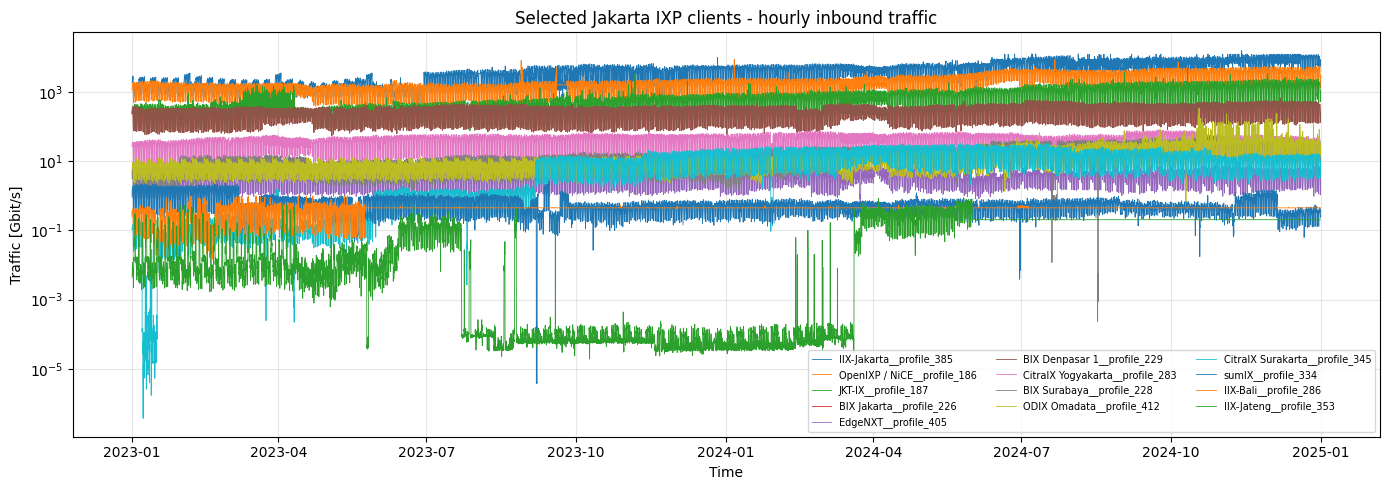

In [ ]:
# ========================
# Visualize selected clients
# ========================

plt.figure(figsize=(14, 5))
for name, series in jakarta_series.items():
    plt.plot(series.index, series.values, linewidth=0.6, label=name)

plt.title("Selected Jakarta IXP clients - hourly inbound traffic")
plt.xlabel("Time")
plt.ylabel("Traffic [Gbit/s]")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(DATA_DIR / "federated_selected_jakarta_clients.png", dpi=150)
plt.show()


**Selected IXP clients — hourly inbound traffic.**

The clients span 8 orders of magnitude (10⁻⁵–10³·⁵ Gbit/s) on a log scale, which is why evaluation uses scale-free metrics (NMAE%, R²) rather than raw MAE.
The fuzzy bands are the daily diurnal cycle, and most series drift upward over the two years — clear structure for the GRU to learn.
Note: the pool mixes Jakarta and other Indonesian exchanges (per the Jakarta-first, then-Indonesian selection rule). JKT-IX (profile 187) shows a long near-constant segment around ~10⁻⁴ Gbit/s from mid-2023 on; its overall mean stays high (686 Gbit/s), so it clears the mean filter easily, but that flat stretch may add little signal to the federated model.

## S1.8 Split into federated training clients and held-out test IXPs

We hold out `FL_TEST_IXPS` (3) IXPs completely; they are used only for testing. The split
is stratified by **coefficient of variation** (std / mean), so the held-out set spans
low, medium and high-variability profiles, what actually challenges a forecaster, independently of absolute scale.

In [ ]:
# ========================
# Train / held-out split (stratified by coefficient of variation)
# ========================

def coefficient_of_variation(name):
    s = jakarta_series[name]
    return s.std() / max(s.mean(), 1e-9)

ranked = sorted(jakarta_series, key=coefficient_of_variation)

test_idx = np.linspace(0, len(ranked) - 1, FL_TEST_IXPS, dtype=int)
test_client_names = [ranked[i] for i in test_idx]
train_client_names = [n for n in jakarta_series if n not in test_client_names]

print("Federated training clients:", len(train_client_names))
for name in train_client_names:
    print(f"  TRAIN: {name} | mean: {jakarta_series[name].mean():.4f} Gbit/s "
          f"| CV: {coefficient_of_variation(name):.3f}")

print("\nHeld-out test clients:", len(test_client_names))
for name in test_client_names:
    print(f"  TEST: {name} | mean: {jakarta_series[name].mean():.4f} Gbit/s "
          f"| CV: {coefficient_of_variation(name):.3f}")


Federated training clients: 10
  TRAIN: IIX-Jakarta__profile_385 | mean: 4412.2280 Gbit/s | CV: 0.620
  TRAIN: OpenIXP / NiCE__profile_186 | mean: 2009.9934 Gbit/s | CV: 0.555
  TRAIN: JKT-IX__profile_187 | mean: 686.4326 Gbit/s | CV: 0.690
  TRAIN: BIX Jakarta__profile_226 | mean: 285.6777 Gbit/s | CV: 0.369
  TRAIN: EdgeNXT__profile_405 | mean: 4.1234 Gbit/s | CV: 0.403
  TRAIN: BIX Denpasar 1__profile_229 | mean: 285.6789 Gbit/s | CV: 0.369
  TRAIN: CitraIX Yogyakarta__profile_283 | mean: 40.1676 Gbit/s | CV: 0.394
  TRAIN: BIX Surabaya__profile_228 | mean: 15.2668 Gbit/s | CV: 0.688
  TRAIN: ODIX Omadata__profile_412 | mean: 14.3150 Gbit/s | CV: 0.939
  TRAIN: CitraIX Surakarta__profile_345 | mean: 9.7634 Gbit/s | CV: 0.887

Held-out test clients: 3
  TEST: IIX-Bali__profile_286 | mean: 0.4252 Gbit/s | CV: 0.226
  TEST: sumIX__profile_334 | mean: 0.5962 Gbit/s | CV: 0.579
  TEST: IIX-Jateng__profile_353 | mean: 0.1029 Gbit/s | CV: 1.192


## S1.9 Build per-client datasets

Each client is split temporally into train (60%), validation (10%) and test (30%). The
scaler is fitted **only on that client's training split**.

In [ ]:
# ========================
# Per-client datasets
# ========================

def build_client_dataset(values, n_lookback=FL_N_LOOKBACK, k_horizon=FL_K_HORIZON):
    values = np.asarray(values, dtype=np.float32)

    train_end = int(len(values) * 0.60)
    validation_end = int(len(values) * 0.70)

    train_values = values[:train_end]
    validation_values = values[train_end:validation_end]
    test_values = values[validation_end:]

    scaler = Standardizer().fit(train_values)

    train_xy = make_windows(scaler.transform(train_values), n_lookback, k_horizon, stride=1)
    validation_xy = make_windows(scaler.transform(validation_values), n_lookback, k_horizon, stride=k_horizon)
    test_xy = make_windows(scaler.transform(test_values), n_lookback, k_horizon, stride=k_horizon)

    return {"train": train_xy, "validation": validation_xy, "test": test_xy,
            "scaler": scaler, "raw_values": values}


federated_clients = {n: build_client_dataset(jakarta_series[n].values) for n in train_client_names}
heldout_clients = {n: build_client_dataset(jakarta_series[n].values) for n in test_client_names}

print("Federated clients:", len(federated_clients), "| held-out clients:", len(heldout_clients))
for name, data in federated_clients.items():
    print(f"  {name} | train windows: {data['train'][0].shape}")


Federated clients: 10 | held-out clients: 3
  IIX-Jakarta__profile_385 | train windows: (10498, 24)
  OpenIXP / NiCE__profile_186 | train windows: (10498, 24)
  JKT-IX__profile_187 | train windows: (10498, 24)
  BIX Jakarta__profile_226 | train windows: (10498, 24)
  EdgeNXT__profile_405 | train windows: (10498, 24)
  BIX Denpasar 1__profile_229 | train windows: (10498, 24)
  CitraIX Yogyakarta__profile_283 | train windows: (10498, 24)
  BIX Surabaya__profile_228 | train windows: (10498, 24)
  ODIX Omadata__profile_412 | train windows: (10498, 24)
  CitraIX Surakarta__profile_345 | train windows: (10498, 24)


## S1.10 Local client update (with FedProx)

Each round, a client receives the global weights, trains locally for a few epochs and
returns the updated weights. The FedProx proximal term penalizes drift from the global
model, which stabilizes training on the non-IID clients.

In [ ]:
# ========================
# Local client update
# ========================

def local_client_update(global_state_dict, train_xy, local_epochs, learning_rate, mu=FL_MU):
    local_model = FederatedGRUForecaster(
        horizon=FL_K_HORIZON, hidden_size=FL_HIDDEN_SIZE,
        num_layers=FL_NUM_LAYERS, dropout=FL_DROPOUT,
    ).to(DEVICE)
    local_model.load_state_dict(global_state_dict)

    global_params = [p.detach().clone() for p in local_model.parameters()]

    optimizer = torch.optim.Adam(local_model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    X_train, Y_train = train_xy
    loader = make_loader(X_train, Y_train, FL_BATCH_SIZE, shuffle=True)

    local_model.train()
    for _ in range(local_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(local_model(xb), yb)

            if mu > 0:
                proximal = 0.0
                for lp, gp in zip(local_model.parameters(), global_params):
                    proximal = proximal + ((lp - gp) ** 2).sum()
                loss = loss + (mu / 2.0) * proximal

            loss.backward()
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=1.0)
            optimizer.step()

    return local_model.state_dict(), len(X_train)


## S1.11 FedAvg aggregation

The server averages the local models, weighting each client by its number of training
windows.

In [ ]:
# ========================
# FedAvg aggregation
# ========================

def federated_average(client_states, client_sizes):
    total = sum(client_sizes)
    averaged = {}
    for key in client_states[0].keys():
        averaged[key] = sum(
            state[key].float() * (size / total)
            for state, size in zip(client_states, client_sizes)
        )
    return averaged


## S1.12 Evaluation on held-out IXPs (objective metrics)

Each model is evaluated per held-out IXP with the scale-free metrics defined above,
including the persistence skill score.

In [ ]:
# ========================
# Evaluation
# ========================

def evaluate_model_on_clients(model, clients, include_persistence=True):
    rows = []
    for name, data in clients.items():
        X_test, Y_test = data["test"]
        scaler = data["scaler"]

        pred = scaler.inverse(predict_torch_model(model, X_test))
        true = scaler.inverse(Y_test)

        y_persist = None
        if include_persistence:
            persist_scaled = persistence_prediction(X_test, Y_test.shape[1])
            y_persist = scaler.inverse(persist_scaled)

        metrics = compute_forecast_metrics(true, pred, y_persist)
        metrics["IXP"] = name
        rows.append(metrics)
    return pd.DataFrame(rows)


## S1.13 Run Federated Learning

A global GRU is trained with FedAvg for several rounds. Convergence is tracked with the
**mean NMAE%** across held-out IXPs (scale-free), not raw MAE.

In [ ]:
# ========================
# Run Federated Learning
# ========================

set_seed(SEED)

global_model = FederatedGRUForecaster(
    horizon=FL_K_HORIZON, hidden_size=FL_HIDDEN_SIZE,
    num_layers=FL_NUM_LAYERS, dropout=FL_DROPOUT,
).to(DEVICE)

federated_history = []
start_time = time.time()

for round_idx in range(1, FL_ROUNDS + 1):
    global_state = copy.deepcopy(global_model.state_dict())

    client_states, client_sizes = [], []
    for client_name, client_data in federated_clients.items():
        local_state, local_size = local_client_update(
            global_state_dict=global_state,
            train_xy=client_data["train"],
            local_epochs=FL_LOCAL_EPOCHS,
            learning_rate=FL_LEARNING_RATE,
        )
        client_states.append(local_state)
        client_sizes.append(local_size)

    global_model.load_state_dict(federated_average(client_states, client_sizes))

    round_metrics = evaluate_model_on_clients(global_model, heldout_clients)
    mean_nmae = round_metrics["NMAE_pct"].mean()
    mean_r2 = round_metrics["R2"].mean()

    federated_history.append({
        "round": round_idx,
        "mean_NMAE_pct": mean_nmae,
        "mean_R2": mean_r2,
    })
    print(f"Round {round_idx:02d}/{FL_ROUNDS} | held-out NMAE: {mean_nmae:6.2f}% | held-out R2: {mean_r2:.3f}")

federated_training_time = time.time() - start_time
federated_history = pd.DataFrame(federated_history)

display(federated_history)
print(f"Federated training time: {federated_training_time:.2f} s")


Round 01/15 | held-out NMAE:  36.89% | held-out R2: -17.058
Round 02/15 | held-out NMAE:  34.09% | held-out R2: -4.482
Round 03/15 | held-out NMAE:  22.11% | held-out R2: -17.949
Round 04/15 | held-out NMAE:  19.74% | held-out R2: -24.009
Round 05/15 | held-out NMAE:  17.55% | held-out R2: -23.052
Round 06/15 | held-out NMAE:  16.51% | held-out R2: -25.413
Round 07/15 | held-out NMAE:  15.34% | held-out R2: -18.201
Round 08/15 | held-out NMAE:  15.21% | held-out R2: -20.306
Round 09/15 | held-out NMAE:  15.52% | held-out R2: -22.388
Round 10/15 | held-out NMAE:  14.79% | held-out R2: -15.354
Round 11/15 | held-out NMAE:  14.80% | held-out R2: -14.611
Round 12/15 | held-out NMAE:  14.41% | held-out R2: -10.208
Round 13/15 | held-out NMAE:  13.95% | held-out R2: -7.504
Round 14/15 | held-out NMAE:  13.92% | held-out R2: -8.487
Round 15/15 | held-out NMAE:  13.55% | held-out R2: -6.006


,round,mean_NMAE_pct,mean_R2
0,1,36.885697,-17.057890
1,2,34.091334,-4.481935
2,3,22.105249,-17.948586
3,4,19.739809,-24.009467
4,5,17.546502,-23.052049
5,6,16.505275,-25.413312
6,7,15.343920,-18.201434
7,8,15.205329,-20.305837
8,9,15.523566,-22.388199
9,10,14.785278,-15.354473


Federated training time: 114.13 s


## S1.14 Centralized GRU baseline
A single model trained on the **pooled** (per-client standardized)
data of all training clients, as if the IXPs could share their data with a central server.
It uses the same architecture and the same per-client standardized windows as the
federated model, only pooled instead of federated, and the same generous training budget
as the local baseline for a fair comparison.
It is evaluated on the same held-out IXPs.

In [ ]:
# ========================
# Centralized baseline (pooled training data)
# ========================

X_central_train = np.concatenate([federated_clients[n]["train"][0] for n in train_client_names])
Y_central_train = np.concatenate([federated_clients[n]["train"][1] for n in train_client_names])

# Pool the (non-empty) validation windows for early stopping.
val_X_parts = [federated_clients[n]["validation"][0] for n in train_client_names
               if len(federated_clients[n]["validation"][0]) > 0]
val_Y_parts = [federated_clients[n]["validation"][1] for n in train_client_names
               if len(federated_clients[n]["validation"][1]) > 0]
X_central_val = np.concatenate(val_X_parts)
Y_central_val = np.concatenate(val_Y_parts)

print("Centralized pooled train windows:", X_central_train.shape)
print("Centralized pooled val windows:  ", X_central_val.shape)

set_seed(SEED)
centralized_model = FederatedGRUForecaster(
    horizon=FL_K_HORIZON, hidden_size=FL_HIDDEN_SIZE,
    num_layers=FL_NUM_LAYERS, dropout=FL_DROPOUT,
).to(DEVICE)

centralized_model, _, _, centralized_training_time = train_torch_forecaster(
    model=centralized_model,
    X_train=X_central_train, Y_train=Y_central_train,
    X_validation=X_central_val, Y_validation=Y_central_val,
    learning_rate=FL_LEARNING_RATE,
    max_epochs=BASELINE_MAX_EPOCHS,
    patience=BASELINE_PATIENCE,
    batch_size=FL_BATCH_SIZE,
    verbose=False,
)

print(f"Centralized training time: {centralized_training_time:.2f} s")


Centralized pooled train windows: (104980, 24)
Centralized pooled val windows:   (2880, 24)
Centralized training time: 89.61 s


## S1.15 Local baselines and three-way comparison

For each held-out IXP we train a **local** model on that IXP's own training split (same
generous budget as the centralized model, so the comparison is fair), then compare
**Local vs. Federated vs. Centralized** on identical test windows using the scale-free
metrics.

In [ ]:
# ========================
# Local baselines + Local / Federated / Centralized comparison
# ========================

comparison_rows = []

for client_name, client_data in heldout_clients.items():
    print("Training local model for:", client_name)

    set_seed(SEED)
    local_model = FederatedGRUForecaster(
        horizon=FL_K_HORIZON, hidden_size=FL_HIDDEN_SIZE,
        num_layers=FL_NUM_LAYERS, dropout=FL_DROPOUT,
    ).to(DEVICE)

    local_model, _, _, local_training_time = train_torch_forecaster(
        model=local_model,
        X_train=client_data["train"][0], Y_train=client_data["train"][1],
        X_validation=client_data["validation"][0], Y_validation=client_data["validation"][1],
        learning_rate=FL_LEARNING_RATE,
        max_epochs=BASELINE_MAX_EPOCHS,
        patience=BASELINE_PATIENCE,
        batch_size=FL_BATCH_SIZE,
        verbose=False,
    )

    single = {client_name: client_data}
    models = {
        "Local": (local_model, local_training_time),
        "Federated": (global_model, federated_training_time),
        "Centralized": (centralized_model, centralized_training_time),
    }

    for model_name, (model, t_train) in models.items():
        m = evaluate_model_on_clients(model, single).iloc[0].to_dict()
        comparison_rows.append({
            "IXP": client_name,
            "model": model_name,
            "MAE_Gbps": m["MAE_Gbps"],
            "RMSE_Gbps": m["RMSE_Gbps"],
            "NMAE_pct": m["NMAE_pct"],
            "NRMSE_pct": m["NRMSE_pct"],
            "R2": m["R2"],
            "skill_vs_persistence": m["skill_vs_persistence"],
        })

fl_results = pd.DataFrame(comparison_rows)
display(fl_results.round(3))

fl_results.to_csv(DATA_DIR / "federated_vs_centralized_vs_local_results.csv", index=False)
print("Saved:", DATA_DIR / "federated_vs_centralized_vs_local_results.csv")


Training local model for: IIX-Bali__profile_286
Training local model for: sumIX__profile_334
Training local model for: IIX-Jateng__profile_353


,IXP,model,MAE_Gbps,RMSE_Gbps,NMAE_pct,NRMSE_pct,R2,skill_vs_persistence
0,IIX-Bali__profile_286,Local,0.003,0.005,0.622,1.092,0.094,-3.679
1,IIX-Bali__profile_286,Federated,0.021,0.022,4.687,4.914,-17.327,-34.228
2,IIX-Bali__profile_286,Centralized,0.007,0.008,1.581,1.873,-1.664,-10.884
3,sumIX__profile_334,Local,0.061,0.088,12.206,17.655,0.838,0.613
4,sumIX__profile_334,Federated,0.064,0.091,12.788,18.274,0.826,0.595
5,sumIX__profile_334,Centralized,0.052,0.078,10.367,15.576,0.874,0.671
6,IIX-Jateng__profile_353,Local,0.044,0.059,21.209,28.440,-0.865,-15.580
7,IIX-Jateng__profile_353,Federated,0.048,0.069,23.177,33.040,-1.517,-17.119
8,IIX-Jateng__profile_353,Centralized,0.059,0.077,28.305,37.048,-2.165,-21.128


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/federated_vs_centralized_vs_local_results.csv


## S1.16 Visualizations

Convergence (mean NMAE% on held-out IXPs) and the three-way per-IXP comparison on the
scale-free NMAE% metric.

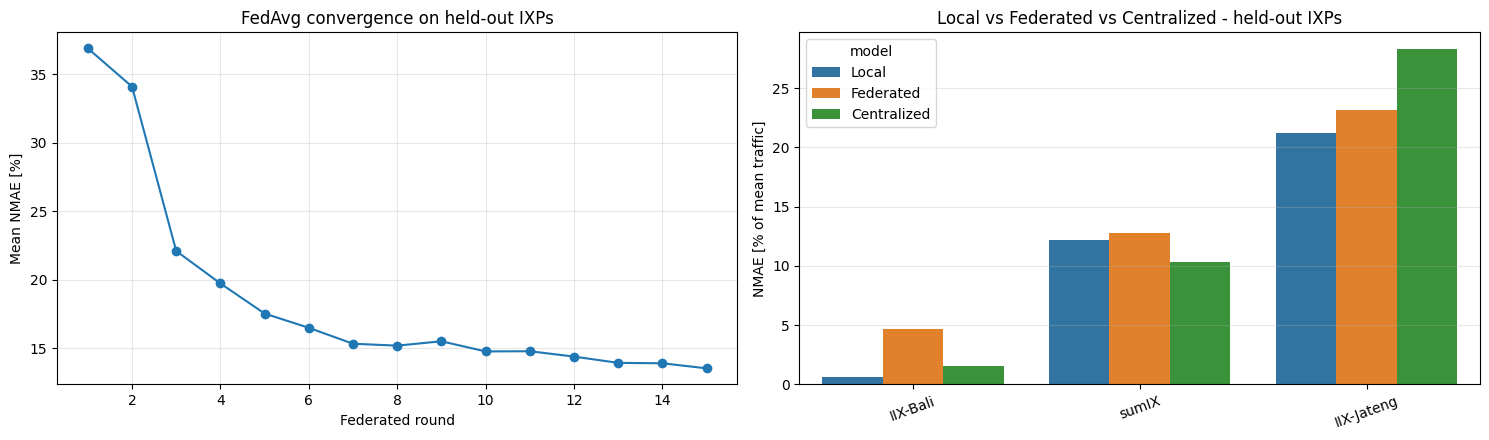

In [ ]:
# ========================
# Visualizations
# ========================

fl_results_plot = fl_results.copy()
fl_results_plot["IXP_short"] = fl_results_plot["IXP"].str.replace(r"__profile_\d+", "", regex=True)

model_order = ["Local", "Federated", "Centralized"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Convergence
axes[0].plot(federated_history["round"], federated_history["mean_NMAE_pct"], marker="o")
axes[0].set_title("FedAvg convergence on held-out IXPs")
axes[0].set_xlabel("Federated round")
axes[0].set_ylabel("Mean NMAE [%]")
axes[0].grid(alpha=0.3)

# Per-IXP NMAE comparison
sns.barplot(data=fl_results_plot, x="IXP_short", y="NMAE_pct", hue="model",
            hue_order=model_order, ax=axes[1])
axes[1].set_title("Local vs Federated vs Centralized - held-out IXPs")
axes[1].set_xlabel("")
axes[1].set_ylabel("NMAE [% of mean traffic]")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="model")

plt.tight_layout()
plt.savefig(DATA_DIR / "federated_learning_comparison_nmae.png", dpi=150)
plt.show()


### Analysis: convergence and three-way comparison

On the convergence side (left plot), the average NMAE on the held-out IXPs drops from about 37% to 13.5%. Most of the drop happens in the first 3-4 rounds and the curve is essentially flat after round 7, so FedAvg trains smoothly and FL_ROUNDS = 15 is more than enough.

The right plot compares the per-IXP error (NMAE%, scale-free):

| Held-out IXP | Local | Federated | Centralized |
|---|---|---|---|
| IIX-Bali   | ~0.6%  | ~4.7%  | ~1.6%  |
| sumIX      | ~12.2% | ~12.8% | ~10.4% |
| IIX-Jateng | ~21.2% | ~23.2% | ~28.3% |

Federated is never the best: it loses the most on the easiest IXP (IIX-Bali), where mixing many very different IXPs into one shared model hurts a series that a model trained on its own data predicts almost perfectly. Centralized is not the best either: it wins on sumIX but is the worst on IIX-Jateng, because when all the data is pooled the big, busy IXPs take over the shared model. The IXPs are simply very different from each other (errors from 0.6% up to 28%), and in our opinion this variety is the real limit, more than the training method.

Two caveats: with only 3 held-out IXPs this is a rough picture rather than a solid result, and those 3 are the non-Jakarta filler IXPs, so the test does not really measure Jakarta.

Overall, FedAvg trains cleanly but does not beat a model trained on each IXP alone, and pooling does not help either: here privacy comes at a cost in accuracy.

## S1.17 Summary

In [ ]:
# ========================
# Aggregate summary
# ========================

summary = (
    fl_results
    .groupby("model")[["NMAE_pct", "NRMSE_pct", "R2", "skill_vs_persistence"]]
    .mean()
    .reindex(["Local", "Federated", "Centralized"])
)

print("Mean over held-out IXPs (scale-free metrics):")
display(summary.round(3))

best_nmae = summary["NMAE_pct"].idxmin()
print(f"\nLowest mean NMAE%: {best_nmae}")
print("Positive skill_vs_persistence means the model beats a naive last-value forecast.")


Mean over held-out IXPs (scale-free metrics):


,NMAE_pct,NRMSE_pct,R2,skill_vs_persistence
model,,,,
Local,11.346,15.729,0.022,-6.215
Federated,13.551,18.743,-6.006,-16.917
Centralized,13.418,18.166,-0.985,-10.447



Lowest mean NMAE%: Local
Positive skill_vs_persistence means the model beats a naive last-value forecast.


### Mean over held-out IXPs (scale-free metrics)

- **Local is best on every metric** — lowest errors (NMAE%/NRMSE%), highest R², and the least-bad skill score. Federated and Centralized are close to each other and both clearly worse.
- **All three skill scores are negative.** On average, **none of the models beats a naive "repeat the last value" forecast**. The shared models are the worst (Federated -16.9), so their global weights actually hurt compared to just repeating the last value.
- **R² is near zero or very negative** (Federated -6.0): the shared models explain almost none of the ups and downs in the held-out data. Only Local is barely positive (0.022).
- This matches the per-IXP plot: with few, very different IXPs, averaging the models (FedAvg) makes things worse, and pooling all the data (Centralized) doesn't fix it.

This is an average over only 3 held-out IXPs, all non-Jakarta filler IXPs, so the numbers are noisy and don't really measure Jakarta. The main point: right now a naive baseline is the one to beat, and **a separate or fine-tuned model per IXP** looks like the better path.

## S1.18 Save the federated model

In [ ]:
# ========================
# Save federated model
# ========================

torch.save(
    {
        "model_state_dict": global_model.state_dict(),
        "FL_N_LOOKBACK": FL_N_LOOKBACK,
        "FL_K_HORIZON": FL_K_HORIZON,
        "FL_HIDDEN_SIZE": FL_HIDDEN_SIZE,
        "FL_NUM_LAYERS": FL_NUM_LAYERS,
        "FL_DROPOUT": FL_DROPOUT,
        "FL_ROUNDS": FL_ROUNDS,
        "FL_LOCAL_EPOCHS": FL_LOCAL_EPOCHS,
        "train_clients": train_client_names,
        "heldout_clients": test_client_names,
        "jakarta_city_tokens": sorted(JAKARTA_CITY_TOKENS),
        "min_mean_gbps": FL_MIN_MEAN_GBPS,
    },
    DATA_DIR / "federated_gru_model_jakarta.pt",
)

print("Saved:", DATA_DIR / "federated_gru_model_jakarta.pt")


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/federated_gru_model_jakarta.pt
